The target is fairly balanced across 7 classes. Obesity Type I is the most common; Insufficient Weight is the least common. No severe imbalance.

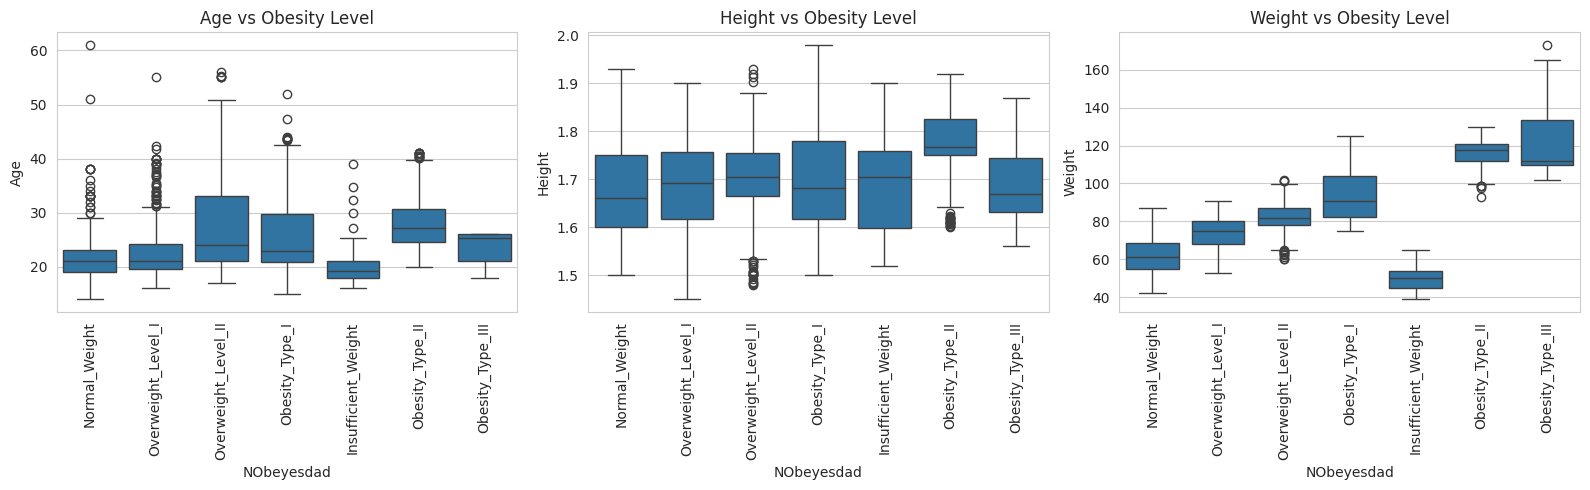

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='NObeyesdad', y='Age', data=df, ax=axes[0])
axes[0].set_title("Age vs Obesity Level")
axes[0].tick_params(axis='x', rotation=90)

sns.boxplot(x='NObeyesdad', y='Height', data=df, ax=axes[1])
axes[1].set_title("Height vs Obesity Level")
axes[1].tick_params(axis='x', rotation=90)

sns.boxplot(x='NObeyesdad', y='Weight', data=df, ax=axes[2])
axes[2].set_title("Weight vs Obesity Level")
axes[2].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Weight clearly separates obesity levels — Obesity Type III has the highest weight. Height also varies by class. Age shows some separation. These features will be important predictors.

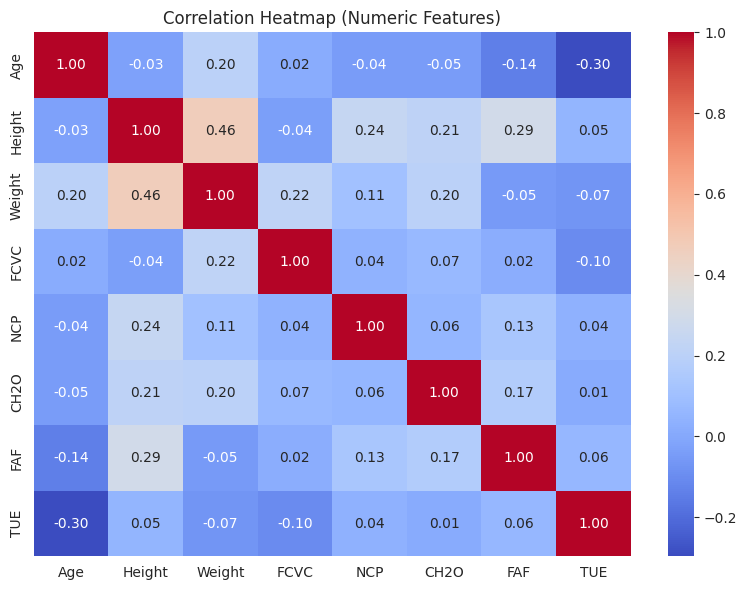

In [7]:
plt.figure(figsize=(8, 6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

Weight and Height are moderately correlated. Most other numeric features are weakly correlated, meaning they carry independent information.

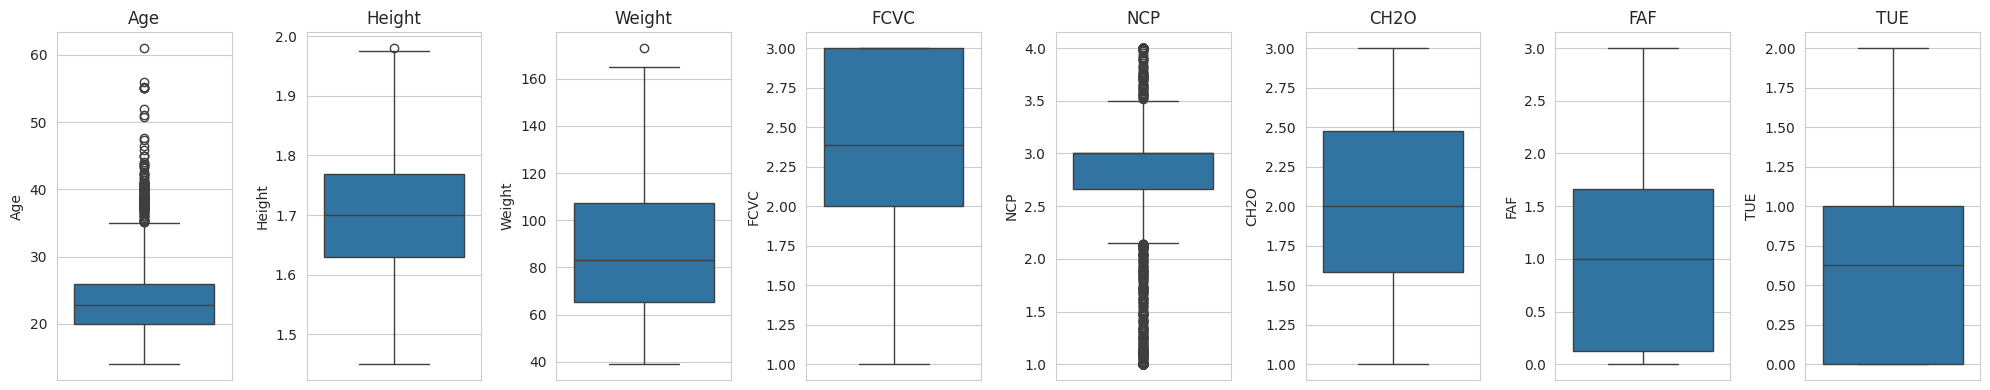

Age: 168 outliers (8.0%)
Height: 1 outliers (0.0%)
Weight: 1 outliers (0.0%)
FCVC: 0 outliers (0.0%)
NCP: 579 outliers (27.4%)
CH2O: 0 outliers (0.0%)
FAF: 0 outliers (0.0%)
TUE: 0 outliers (0.0%)


In [8]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(1, len(numeric_cols), figsize=(20, 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

# IQR-based outlier count
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col}: {outliers} outliers ({outliers/len(df)*100:.1f}%)")

Some features (Age, NCP, CH2O) have mild outliers. These are plausible real values (e.g., older individuals), not data errors. We will keep them but note that scaling reduces their impact. Tree-based models are robust to outliers anyway.